In [ ]:
!git clone https://github.com/czczup/FAST.git
!git clone https://github.com/GXYM/KPN.git
!git clone https://github.com/GXYM/TextPMs.git
!git clone https://github.com/frotms/PaddleOCR2Pytorch.git

Cloning into 'Signboard-Text-Detection-and-Recognition-in-Streaming-Video'...
remote: Enumerating objects: 306, done.
remote: Counting objects: 100% (306/306), done.
remote: Compressing objects: 100% (242/242), done.
remote: Total 306 (delta 65), reused 294 (delta 53), pack-reused 0 (from 0)
Receiving objects: 100% (306/306), 27.18 MiB | 37.11 MiB/s, done.
Resolving deltas: 100% (65/65), done.
Cloning into 'FAST'...
remote: Enumerating objects: 305, done.
remote: Counting objects: 100% (74/74), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 305 (delta 44), reused 15 (delta 15), pack-reused 231 (from 1)
Receiving objects: 100% (305/305), 2.43 MiB | 17.89 MiB/s, done.
Resolving deltas: 100% (132/132), done.
Cloning into 'KPN'...
remote: Enumerating objects: 65, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 65 (delta 22), reused 46 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (65/65), 

In [2]:
!pip install -q fvcore scipy==1.10.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.1/34.1 MB 59.3 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mne 1.10.1 requires scipy>=1.11, but you have scipy 1.10.1 which is incompatible.
kaggle-environments 1.18.0 requires scipy>=1.11.2, but you have scipy 1.10.1 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.5.2 requires scipy>=1.11.1, but you have scipy 1.10.1 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3

In [ ]:
import torch
import os
import cv2
import numpy as np
import json
import gdown
import random
import time
import string
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
from pathlib import Path
from PIL import Image
from utils.transforms import convert_box_format, check_and_refine_valid_box
from utils.visualize import overlay, draw_polygon
from tqdm import tqdm 
from fvcore.nn import FlopCountAnalysis, parameter_count
from argparse import Namespace 
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
device = ("cuda" if torch.cuda.is_available() else "cpu")

if not hasattr(np, 'bool'):
    np.bool = bool


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)               # CPU
    torch.cuda.manual_seed(seed)          # GPU
    torch.cuda.manual_seed_all(seed)      # Multi-GPU (nếu có)

    # For deterministic behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

/tmp/ipykernel_38/121858151.py:29: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, 'bool'):


In [ ]:
class SignboardText(Dataset):
    def __init__(self, image_data, annotation_data, transforms=None, TextInstance=None, method=None):
        self.image_data = image_data

        self.image_list = os.listdir(image_data)
        self.annotation_lookup = self.read_json(annotation_data)
        self.transforms = transforms 
        self.TextInstance = TextInstance
        self.method = method

    def read_json(self, file): 
        with open(file, 'r') as file: 
            data = json.load(file)

        # Create mapping: id images and image_id annotations
        annotations_lookup = defaultdict(list)
        for info in data['annotations']:
            annotations_lookup[info['image_id']].append(info)

        return annotations_lookup

    def extract_info(self, info):
        labels = []
        for p in info:
            object = {}
            bbox = p['bbox']
            seg = p['segmentation']
            transcript = p['transcription']

            object['bbox'] = bbox
            object['segmentation'] = seg
            object['transcription'] = transcript

            labels.append(object)

        return labels

    def __len__(self):
        return len(self.image_list)
    
    def __getitem__(self, index):
        image_name = self.image_list[index]
        image_id = os.path.join(Path(self.image_data).name, image_name)
        image_path = os.path.join(self.image_data, image_name)
        info = self.annotation_lookup.get(image_id)
        if info is not None: labels = self.extract_info(info)
        else: 
            print(image_path)
            labels = None 

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image_height, image_width = image.shape[:2]
        gt = {
            'file_name': image_id, 
            'image_size': image.shape[:2],
        }
        polygons, transcriptions = [], []
        if labels is not None: 
            for i, label in enumerate(labels): 
                segmentation = label['segmentation']
                transcription = label['transcription']
                bbox = label['bbox']
                new_bbox = check_and_refine_valid_box(bbox, image_width, image_height)
                if new_bbox is None: continue
                polygons.append(segmentation)
                transcriptions.append(transcription)

        if self.transforms is not None:
            if self.method == 'dbnet': 
                data = dict(image=image)
                image, shape_list = self.transforms(data)
                gt['shape_list'] = shape_list

            if self.method in ['textpms', 'kpn']: 
                image, _ = self.transforms(image, polygons=None)

            if self.method in ['fast', 'pan']: 
                image = self.transforms(image)

        if image.shape[-1] == 3: 
            image = image.transpose(2, 0, 1) # C, H, W

        if not isinstance(image, torch.Tensor):
            image = torch.from_numpy(image)
            
        gt['image'] = image
        gt['polygons'] = torch.from_numpy(np.array([polygon for polygon in polygons],
                                                  dtype=np.int32))
        gt['transcriptions'] = [transcription for transcription in transcriptions]

        return gt

In [ ]:
def measure_fps(model, image, postprocess=None, cfg=None, num_runs=100, method=None):
    model.eval()
    # Warm-up
    with torch.inference_mode():
        for _ in range(10):
            if method == 'textpms':
                preds, *_ = model(image)
                if postprocess is not None: 
                    b, c, h, w = image.shape
                    preds = torch.sigmoid(preds[0, :, :h//cfg.scale, :w//cfg.scale])
                    preds = preds.cpu().numpy()
    
                    _ = postprocess(preds, cfg.scale)
            if method == 'kpn': 
                pred_cls, pred_centergauss, pred_KPN_cls, list_pred_xys, *_ = model(image, istrain=False)
                if postprocess is not None: 
                    preds = (torch.sigmoid(pred_KPN_cls)).detach().cpu().numpy()[0]
                    pred_xys = list_pred_xys[0].detach().cpu().numpy().astype(np.float32)
                    _ = postprocess.get_contours(preds, kernel_postions=pred_xys, 
                                                 floodfill=cfg.eval_vis)
            if method == 'fast':
                f = model.backbone(image) 
                f = model.neck(f)
                f = model.det_head(f)
                if postprocess is not None: 
                    det_out = model._upsample(f, image.size(), scale=4)
                    _ = postprocess(det_out, cfg.img_metas, cfg, scale=2)
            if method == 'pan': 
                f = model.backbone(image)
                f1 = model.reduce_layer1(f[0])
                f2 = model.reduce_layer2(f[1])
                f3 = model.reduce_layer3(f[2])
                f4 = model.reduce_layer4(f[3])
                
                # FPEM
                f1_1, f2_1, f3_1, f4_1 = model.fpem1(f1, f2, f3, f4)
                f1_2, f2_2, f3_2, f4_2 = model.fpem2(f1_1, f2_1, f3_1, f4_1)
                
                # FFM
                f1 = f1_1 + f1_2
                f2 = f2_1 + f2_2
                f3 = f3_1 + f3_2
                f4 = f4_1 + f4_2
                f2 = model._upsample(f2, f1.size())
                f3 = model._upsample(f3, f1.size())
                f4 = model._upsample(f4, f1.size())
                f = torch.cat((f1, f2, f3, f4), 1)
                f = model.det_head(f)

                if postprocess is not None: 
                    det_out = model._upsample(f, image.size(), scale=4)
                    _ = postprocess(det_out, cfg.img_metas, cfg)
                
            if method == 'dbnet++': 
                outputs = model(image)
                if postprocess is not None: 
                    preds = dict(maps = outputs['maps'].cpu().numpy())
    
                    _ = postprocess(preds, cfg.shape_list)
    
    # Measure FPS
    torch.cuda.synchronize()
    start = time.time()
    
    with torch.inference_mode():
        for _ in range(num_runs):
            if method == 'textpms':
                preds, *_ = model(image)
                if postprocess is not None:
                    b, c, h, w = image.shape
                    preds = torch.sigmoid(preds[0, :, :h//cfg.scale, :w//cfg.scale])
                    preds = preds.cpu().numpy()
    
                    _ = postprocess(preds, cfg.scale)
            if method == 'kpn': 
                pred_cls, pred_centergauss, pred_KPN_cls, list_pred_xys, *_ = model(image, istrain=False)
                if postprocess is not None: 
                    preds = (torch.sigmoid(pred_KPN_cls)).detach().cpu().numpy()[0]
                    pred_xys = list_pred_xys[0].detach().cpu().numpy().astype(np.float32)
                    _ = postprocess.get_contours(preds, kernel_postions=pred_xys, 
                                                 floodfill=cfg.eval_vis)
            if method == 'fast':
                f = model.backbone(image) 
                f = model.neck(f)
                f = model.det_head(f)
                if postprocess is not None: 
                    det_out = model._upsample(f, image.size(), scale=4)
                    _ = postprocess(det_out, cfg.img_metas, cfg, scale=2)
            if method == 'pan': 
                f = model.backbone(image)
                f1 = model.reduce_layer1(f[0])
                f2 = model.reduce_layer2(f[1])
                f3 = model.reduce_layer3(f[2])
                f4 = model.reduce_layer4(f[3])
                
                # FPEM
                f1_1, f2_1, f3_1, f4_1 = model.fpem1(f1, f2, f3, f4)
                f1_2, f2_2, f3_2, f4_2 = model.fpem2(f1_1, f2_1, f3_1, f4_1)
                
                # FFM
                f1 = f1_1 + f1_2
                f2 = f2_1 + f2_2
                f3 = f3_1 + f3_2
                f4 = f4_1 + f4_2
                f2 = model._upsample(f2, f1.size())
                f3 = model._upsample(f3, f1.size())
                f4 = model._upsample(f4, f1.size())
                f = torch.cat((f1, f2, f3, f4), 1)
                f = model.det_head(f)

                if postprocess is not None: 
                    det_out = model._upsample(f, image.size(), scale=4)
                    _ = postprocess(det_out, cfg.img_metas, cfg)
                
            if method == 'dbnet++': 
                outputs = model(image)
                if postprocess is not None: 
                    preds = dict(maps = outputs['maps'].cpu().numpy())
    
                    _ = postprocess(preds, cfg.shape_list)
            
    torch.cuda.synchronize()
    end = time.time()
    
    avg_time = (end - start) / num_runs
    fps = 1 / avg_time

    print(f"Average time per frame: {avg_time*1000:.2f} ms")
    
    return fps

def measure_flops(model, image): 
    flops = FlopCountAnalysis(model, image).total() / 1e9
    return flops

def measure_params(model): 
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
    non_trainable = sum(p.numel() for p in model.parameters() if not p.requires_grad) / 1e6
    total = trainable + non_trainable

    return total, trainable, non_trainable

In [ ]:
PRED_ICDAR = 'Prediction_ICDAR'

def create_folder(folder): 
    if not Path(folder).is_dir():
        Path(folder).mkdir(parents=True, exist_ok=True)

def rescale_box(image, orig_size, boxes=None):
    assert len(image.shape) == 4
    original_height, original_width = orig_size
    transformed_height, transformed_width = image.shape[2:] # B, C, H, W
    ratio = [original_width / transformed_width, original_height / transformed_height]

    if boxes is not None: 
        boxes = [np.round(box * ratio).astype(np.int32) for box in boxes] 

    return boxes

def save_output_txt(file_name, polygons, transcriptions, boxes=None): 
    sub_folder, file = Path(file_name).parent, Path(file_name).with_suffix('.txt').name
    pred_icdar_folder = os.path.join(PRED_ICDAR, sub_folder)

    create_folder(pred_icdar_folder)
    pred_icdar_file = os.path.join(pred_icdar_folder, file)
    if len(polygons) > 0: 
        if boxes is not None: 
            with open(pred_icdar_file, 'w') as f: 
                for box in boxes: 
                    line = box.flatten()
                    f.write(','.join(map(str, line)) + '\n')

In [8]:
from collections import OrderedDict
def get_state_dict(state_dict):
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k[7:] # remove module.
        new_state_dict[name] = v
    return new_state_dict

def collate_fn(batch): 
    return {
        'file_name': [b['file_name'] for b in batch],
        'image_size': [b['image_size'] for b in batch],
        'image': torch.stack([b['image'] for b in batch]),
        'polygons': torch.stack([b['polygons'] for b in batch]),
        'transcriptions': [b['transcriptions'] for b in batch]
    }

In [9]:
# Prepare data for calculate fps, flops
image = cv2.imread('/kaggle/input/signboardtext/original_images/vietsignboard/baker-1.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
orig_size = image.shape[:2]
image = cv2.resize(image, (640, 640))
image = torch.from_numpy(np.ascontiguousarray(image).transpose(2, 0, 1)).unsqueeze(dim=0).type(torch.float32).to(device)

### TextPMs

In [10]:
%cd /kaggle/working/TextPMs

/kaggle/working/TextPMs


In [11]:
from util.config import config, update_config
from network.textnet import TextNet
from util.option import BaseOptions
from util.augmentation import BaseTransform
from util.detection import watershed_segment
from util.eval import data_transfer_ICDAR
from dataset.dataload import TextInstance

In [ ]:
def inference(model, image, config): 
    model.eval()
    
    b, c, h, w = image.shape
    with torch.inference_mode(): 
        preds, backbone_time, iter_time = model(image)
        preds = torch.sigmoid(preds[0, :, :h//config.scale, :w//config.scale])
        preds = preds.cpu().numpy()

        labels, _, contours = watershed_segment(preds, config.scale)
        boxes = data_transfer_ICDAR(contours)

    return boxes

In [13]:
# Download pretrained model
file_id = '1JKVqjZAZs4mckhH7KiC7sNDqUw8Ib1Km'
url_model = f'https://drive.google.com/uc?id={file_id}'

gdown.download(url_model, 'TextPMs_Icdar2015.zip', quiet=False)
!unzip /kaggle/working/TextPMs/TextPMs_Icdar2015.zip

Downloading...
From (original): https://drive.google.com/uc?id=1JKVqjZAZs4mckhH7KiC7sNDqUw8Ib1Km
From (redirected): https://drive.google.com/uc?id=1JKVqjZAZs4mckhH7KiC7sNDqUw8Ib1Km&confirm=t&uuid=237d9a1b-86a3-4286-a4cd-5ea23e49c837
To: /kaggle/working/TextPMs/TextPMs_Icdar2015.zip
100%|██████████| 254M/254M [00:02<00:00, 99.9MB/s] 


Archive:  /kaggle/working/TextPMs/TextPMs_Icdar2015.zip
   creating: Icdar2015/
  inflating: Icdar2015/TextPMs_resnet50_370.pth  


In [14]:
option = BaseOptions()
args = option.parser.parse_known_args()
update_config(config, args[0])
config.device = device
if device == "cpu": 
    config.cuda = False

config.threshold = 0.5
# Initialize transform
transforms = BaseTransform(size=config.test_size, mean=config.means, std=config.stds)

In [15]:
english_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/english',
                           annotation_data='/kaggle/input/signboardtext/annotations.json',
                           transforms=transforms,
                          method='textpms')
vietsignboard_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard',
                               annotation_data='/kaggle/input/signboardtext/annotations.json',
                               transforms=transforms,
                                method='textpms')
vin_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vin',
                        annotation_data='/kaggle/input/signboardtext/annotations.json',
                        transforms=transforms,
                      method='textpms')
vietsignboard_line = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard',
                                   annotation_data='/kaggle/input/signboardtext/annotations_line.json',
                                   transforms=transforms,
                                   method='textpms')

In [16]:
viet_dataloader = DataLoader(dataset=vietsignboard_ds, batch_size=1, shuffle=False, collate_fn=collate_fn)
english_dataloader = DataLoader(dataset=english_ds, batch_size=1, shuffle=False, collate_fn=collate_fn)
vin_dataloader = DataLoader(dataset=vin_ds, batch_size=1, shuffle=False, collate_fn=collate_fn)
viet_dataloaderline = DataLoader(dataset=vietsignboard_line, batch_size=1, shuffle=False, collate_fn=collate_fn)

In [17]:
textpm_model = TextNet(is_training=False, backbone=config.net)
checkpoint = torch.load('/kaggle/working/TextPMs/Icdar2015/TextPMs_resnet50_370.pth', map_location=device)
state_dict = checkpoint['model']
textpm_model.load_state_dict(state_dict, strict=True)
textpm_model = textpm_model.to(config.device)

In [16]:
print(f'Shape image: {image.shape}')
fps = measure_fps(textpm_model, image, method='textpms')
postprocess = watershed_segment
fps_and_post = measure_fps(textpm_model, image, postprocess=postprocess, cfg=config, method='textpms')
flops1 = measure_flops(textpm_model.fpn, image)
up1, up2, up3, up4, up5 = textpm_model.fpn(image)
flops2 = measure_flops(textpm_model.rrgn, up1)
flops = flops1 + flops2
total_params, trainable_params, non_trainable_params = measure_params(textpm_model)
print(f'FPS: {fps:.2f}')
print(f'FPS and PostProcess: {fps_and_post:.2f}')
print(f'PostProcess Time: {(abs(fps_and_post - fps)):.2f}')
print(f'FLOPS: {flops:.2f}')
print(f'Total Params: {total_params:.2f}')
print(f'Trainable Params: {trainable_params:.2f}')
print(f'Non Trainable Params: {non_trainable_params:.2f}')

Shape image: torch.Size([1, 3, 640, 640])
Average time per frame: 33.16 ms
Average time per frame: 48.19 ms
FPS: 30.15
FPS and PostProcess: 20.75
PostProcess Time: 9.40
FLOPS: 62.19
Total Params: 36.43
Trainable Params: 36.43
Non Trainable Params: 0.00


In [ ]:
set_seed(42)
for data in tqdm(viet_dataloader): 
    file_name, image = data['file_name'][0], data['image'].to(device)
    polygons = data['polygons'][0, ...].cpu().numpy()
    orig_size = data['image_size'][0]
    transcriptions = data['transcriptions'][0]
    boxes = inference(textpm_model, image, config)
    boxes = rescale_box(image, orig_size, boxes=boxes)
    
    save_output_txt(file_name, polygons, transcriptions, boxes)

 40%|███▉      | 475/1194 [03:52<04:49,  2.49it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-3.jpg


 42%|████▏     | 497/1194 [04:02<05:54,  1.96it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-7.jpg


 50%|█████     | 597/1194 [04:53<05:25,  1.83it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-46.jpg


 52%|█████▏    | 623/1194 [05:05<04:21,  2.18it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-5.jpg


100%|██████████| 1194/1194 [09:46<00:00,  2.04it/s]


In [ ]:
set_seed(42)
for data in tqdm(english_dataloader): 
    file_name, image = data['file_name'][0], data['image'].to(device)
    polygons = data['polygons'][0, ...].cpu().numpy()
    orig_size = data['image_size'][0]
    transcriptions = data['transcriptions'][0]
    boxes = inference(textpm_model, image, config)
    boxes = rescale_box(image, orig_size, boxes=boxes)
    
    save_output_txt(file_name, polygons, transcriptions, boxes)

100%|██████████| 413/413 [02:49<00:00,  2.44it/s]


In [ ]:
set_seed(42)
for data in tqdm(vin_dataloader): 
    file_name, image = data['file_name'][0], data['image'].to(device)
    polygons = data['polygons'][0, ...].cpu().numpy()
    orig_size = data['image_size'][0]
    transcriptions = data['transcriptions'][0]
    boxes = inference(textpm_model, image, config)
    boxes = rescale_box(image, orig_size, boxes=boxes)
    
    save_output_txt(file_name, polygons, transcriptions, boxes)

100%|██████████| 516/516 [04:05<00:00,  2.10it/s]


In [ ]:
set_seed(42)
for data in tqdm(viet_dataloaderline): 
    file_name, image = data['file_name'][0], data['image'].to(device)
    polygons = data['polygons'][0, ...].cpu().numpy()
    orig_size = data['image_size'][0]
    transcriptions = data['transcriptions'][0]
    boxes = inference(textpm_model, image, config)
    boxes, contours = rescale_box(image, orig_size, boxes=boxes)
    
    save_output_txt(file_name, polygons, transcriptions, boxes)

  3%|▎         | 36/1194 [00:16<08:26,  2.29it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/levansy-60.jpg


  3%|▎         | 40/1194 [00:18<11:40,  1.65it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/else-135.jpg


  3%|▎         | 41/1194 [00:19<11:48,  1.63it/s]

...

 99%|█████████▉| 1183/1194 [09:22<00:04,  2.31it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/levansy-12.jpg


100%|█████████▉| 1193/1194 [09:27<00:00,  2.34it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/else-118.jpg


100%|██████████| 1194/1194 [09:28<00:00,  2.10it/s]


In [ ]:
!zip -r prediction_icdar.zip /kaggle/working/TextPMs/Prediction_ICDAR

  adding: kaggle/working/TextPMs/Prediction_ICDAR/ (stored 0%)
  adding: kaggle/working/TextPMs/Prediction_ICDAR/vietsignboard/ (stored 0%)
  adding: kaggle/working/TextPMs/Prediction_ICDAR/vietsignboard/barbershop-35.txt (deflated 62%)
  adding: kaggle/working/TextPMs/Prediction_ICDAR/vietsignboard/baker-9.txt (deflated 52%)
  adding: kaggle/working/TextPMs/Prediction_ICDAR/vietsignboard/foodstore-18.txt (deflated 57%)
  adding: kaggle/working/TextPMs/Prediction_ICDAR/vietsignboard/levansy-50.txt (deflated 60%)
  adding: kaggle/working/TextPMs/Prediction_ICDAR/vietsignboard/else-137.txt (deflated 58%)
  adding: kaggle/working/TextPMs/Prediction_ICDAR/vietsignboard/nganhang-9.txt (deflated 65%)
  adding: kaggle/working/TextPMs/Prediction_ICDAR/vietsignboard/drugstore-26.txt (deflated 67%)
  adding: kaggle/working/TextPMs/Prediction_ICDAR/vietsignboard/fashionshop-45.txt (deflated 48%)
  adding: kaggle/working/TextPMs/Prediction_ICDAR/vietsignboard/trunghoc-14.txt (deflated 57%)
  addin

In [ ]:
set_seed(seed=42)
image = cv2.imread('/kaggle/input/signboardtext/images/train/vietsignboard/levansy-86.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
transformed_image, _ = transforms(image)
transformed_image = torch.from_numpy(transformed_image.transpose(2, 0, 1)).unsqueeze(dim=0).to(device)
b, c, h, w = transformed_image.shape
with torch.inference_mode(): 
    preds, backbone_time, iter_time = textpm_model(transformed_image)
    preds = torch.sigmoid(preds[0, :, :h//config.scale, :w//config.scale])
    preds = preds.cpu().numpy()

labels, boxes, contours = watershed_segment(preds, config.scale)
original_height, original_width = image.shape[:2]
transformed_height, transformed_width = transformed_image.shape[2:]
ratio = [original_width / transformed_width, original_height / transformed_height]
original_contours = [(contour * ratio).astype(np.int32) for contour in contours]
boxes = data_transfer_ICDAR(original_contours)

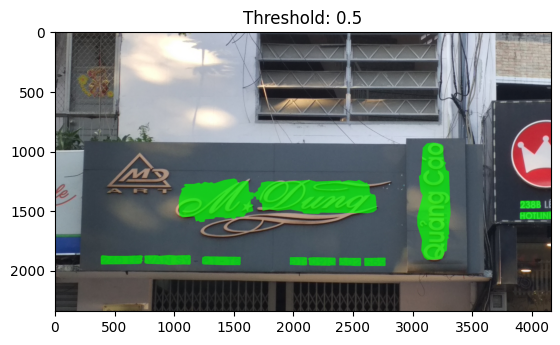

In [23]:
mask = np.zeros(image.shape[:2], np.uint8)
fill_mask = cv2.fillPoly(mask, original_contours, color=1)
prediction = overlay(image, fill_mask, color=(0, 255, 0), alpha=0.7)
plt.imshow(prediction)
plt.title(f'Threshold: {config.threshold}')
plt.show()

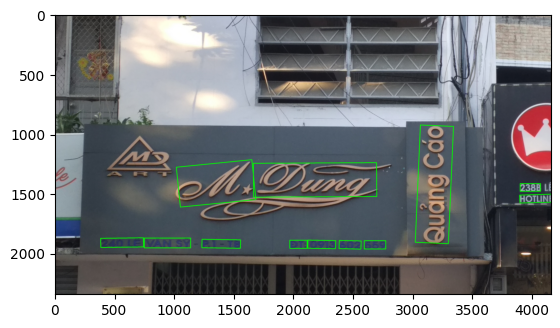

In [24]:
image2 = image.copy()
for box in boxes: 
    draw_polygon(image2, box, thickness=5, color=(0, 255, 0))
plt.imshow(image2)
plt.show()

### KPN

In [10]:
%cd /kaggle/working/KPN

/kaggle/working/KPN


In [11]:
from util.option import BaseOptions
from network.KPN import KPN_Net
from util.augmentation import BaseTransform
from util.config import config as cfg, update_config
from util.detection import TextDetector
from eval_KPN import data_transfer_ICDAR
from dataset.dataload import TextInstance

In [12]:
import time
from shapely.geometry import Polygon
import pyclipper
class PostProcessing(TextDetector):

    #@staticmethod
    def get_contours(self, preds_KPN, kernel_postions=None, floodfill=False):
        #https://blog.csdn.net/qq_37385726/article/details/82313004
        #https://blog.csdn.net/weixin_42296411/article/details/80966724
        t0 = time.time()
        contours_list = []
        bbox_list = []
        if preds_KPN is None:
            return contours_list, bbox_list, 0
        
        preds_KPN_bin = np.where(preds_KPN > self.cfg.score_final_th, 1, 0).astype(np.uint8)
        
        for n in range(preds_KPN_bin.shape[0]):
            repeat_flag = False
            for dc in contours_list:
                if cv2.pointPolygonTest(dc // [self.scale, self.scale], 
                                       (float(kernel_postions[0][n]), float(kernel_postions[1][n])), False) >= 0:
                    repeat_flag = True
                    break
            if repeat_flag:
                continue
            
            if floodfill:
                # SỬA: Chuyển sang integer cho indexing
                y_idx = int(kernel_postions[1][n])
                x_idx = int(kernel_postions[0][n])
                if preds_KPN_bin[n][y_idx, x_idx] == 0:
                    continue
                mask = np.zeros((preds_KPN_bin[n].shape[0]+2, preds_KPN_bin[n].shape[1]+2), dtype=np.uint8)
                seed_p = (x_idx, y_idx)  # SỬA: dùng integer coordinates
                cv2.floodFill(preds_KPN_bin[n], mask, seedPoint=seed_p, newVal=1, flags=cv2.FLOODFILL_MASK_ONLY | 8)
                mask = mask[1:-1, 1:-1]
            else:
                mask = preds_KPN_bin[n]
    
            contours, hierarchy = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
    
            if len(contours):
                max_contour = None
                max_area = 0
                for i in range(len(contours)):
                    # SỬA: Chuyển sang float cho pointPolygonTest
                    if cv2.pointPolygonTest(contours[i], 
                                           (float(kernel_postions[0][n]), float(kernel_postions[1][n])), False) >= 0:
                        local_area = cv2.contourArea(contours[i])
                        if local_area > max_area:
                            max_contour = contours[i]
                            max_area = local_area
                if max_contour is None:
                    continue
    
                epsilon = 0.007 * cv2.arcLength(max_contour, True)
                approx = cv2.approxPolyDP(max_contour, epsilon, True)
                box = approx.reshape((-1, 2)) * [self.scale, self.scale]
                if box.shape[0] < 4:
                    continue
                
                # SỬA: Xử lý Pyclipper offset
                unclip_ratio = 0.15
                poly = Polygon(box)
                distance = poly.area * unclip_ratio / poly.length
                offset = pyclipper.PyclipperOffset()
                offset.AddPath(box, pyclipper.JT_ROUND, pyclipper.ET_CLOSEDPOLYGON)
                expanded = offset.Execute(distance)

                if len(expanded) > 1: 
                    continue
                contours_list.append(np.array(expanded[0]))
                
    
                # Tiếp tục xử lý bbox...
                rect = cv2.minAreaRect(max_contour)
                points = cv2.boxPoints(rect)
                points = np.int0(points)
                bbox_list.append(points * [self.scale, self.scale])
    
        post_time = time.time() - t0
        return contours_list, bbox_list, post_time

In [ ]:
def inference(model, image, config, postprocess): 
    model.eval()
    
    with torch.inference_mode(): 
        pred_cls, pred_centergauss, pred_KPN_cls, list_pred_xys, backbone_time, IM_time = model(image, 
                                                                                                istrain=False)
        preds = (torch.sigmoid(pred_KPN_cls)).detach().cpu().numpy()[0]
        pred_xys = list_pred_xys[0].detach().cpu().numpy().astype(np.float32)
        contours_list, bbox_list, post_time = postprocess.get_contours(preds, kernel_postions=pred_xys, 
                                                                       floodfill=config.eval_vis)
        bboxes = data_transfer_ICDAR(contours_list)

    return bboxes

In [14]:
file_id = '1WvJUTggqYXBkKtu3vSvIJQ_A7b7ZYER9'
url_model = f'https://drive.google.com/uc?id={file_id}'

gdown.download(url_model, 'KPN_model.zip', quiet=False)
!unzip /kaggle/working/KPN/KPN_model.zip

Downloading...
From (original): https://drive.google.com/uc?id=1WvJUTggqYXBkKtu3vSvIJQ_A7b7ZYER9
From (redirected): https://drive.google.com/uc?id=1WvJUTggqYXBkKtu3vSvIJQ_A7b7ZYER9&confirm=t&uuid=dfad848c-c654-41dc-a767-10761711d2da
To: /kaggle/working/KPN/KPN_model.zip
100%|██████████| 648M/648M [00:05<00:00, 118MB/s]  


Archive:  /kaggle/working/KPN/KPN_model.zip
   creating: model/
   creating: model/Ctw1500/
  inflating: model/Ctw1500/TextGraph_resnet50_830.pth  
   creating: model/Icdar2015/
  inflating: model/Icdar2015/TextGraph_resnet50_300.pth  
   creating: model/Totaltext/
  inflating: model/Totaltext/TextGraph_resnet50_810.pth  


In [15]:
option = BaseOptions()
args = option.parser.parse_known_args()
update_config(cfg, args[0])
cfg.exp_name = 'Icdar2015'
cfg.device = device
if device == 'cpu':
    cfg.cuda = False

transforms = BaseTransform(size=cfg.test_size, mean=cfg.means, std=cfg.stds)

In [79]:
english_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/english',
                           annotation_data='/kaggle/input/signboardtext/annotations.json',
                           transforms=transforms,
                          method='kpn')
vietsignboard_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard',
                               annotation_data='/kaggle/input/signboardtext/annotations.json',
                               transforms=transforms,
                                method='kpn')
vin_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vin',
                        annotation_data='/kaggle/input/signboardtext/annotations.json',
                        transforms=transforms,
                      method='kpn')
vietsignboard_line = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard',
                                   annotation_data='/kaggle/input/signboardtext/annotations_line.json',
                                   transforms=transforms,
                                   method='kpn')

In [80]:
viet_dataloader = DataLoader(dataset=vietsignboard_ds, batch_size=1, shuffle=False, collate_fn=collate_fn)
english_dataloader = DataLoader(dataset=english_ds, batch_size=1, shuffle=False, collate_fn=collate_fn)
vin_dataloader = DataLoader(dataset=vin_ds, batch_size=1, shuffle=False, collate_fn=collate_fn)
viet_dataloaderline = DataLoader(dataset=vietsignboard_line, batch_size=1, shuffle=False, collate_fn=collate_fn)

In [16]:
kpn_model = KPN_Net(backbone=cfg.net, is_training=False, cfg=cfg)
kpn_model.load_model(model_path='/kaggle/working/KPN/model/Icdar2015/TextGraph_resnet50_300.pth')
kpn_model = kpn_model.to(cfg.device)
cfg.score_final_th = 0.5
postprocess = PostProcessing(kpn_model, cfg=cfg)

Loading from /kaggle/working/KPN/model/Icdar2015/TextGraph_resnet50_300.pth


In [18]:
print(f'Shape image: {image.shape}')
fps = measure_fps(kpn_model, image, method='kpn')
fps_and_post = measure_fps(kpn_model, image, postprocess=postprocess, cfg=cfg, method='kpn')
flops1 = measure_flops(kpn_model.fpn, image)
if cfg.scale == 1:
    feat_used, up2, up3, up4, up5 = kpn_model.fpn(image)
elif cfg.scale == 2:
    feat_used, up3, up4, up5 = kpn_model.fpn(image)
flops2 = measure_flops(kpn_model.feature, feat_used)
flops = flops1 + flops2
total_params, trainable_params, non_trainable_params = measure_params(kpn_model)
print(f'FPS: {fps:.2f}')
print(f'FPS and PostProcess: {fps_and_post:.2f}')
print(f'PostProcess Time: {(abs(fps_and_post - fps)):.2f}')
print(f'FLOPS: {flops:.2f}')
print(f'Total Params: {total_params:.2f}')
print(f'Trainable Params: {trainable_params:.2f}')
print(f'Non Trainable Params: {non_trainable_params:.2f}')

Shape image: torch.Size([1, 3, 640, 640])
Average time per frame: 63.80 ms
Average time per frame: 240.09 ms
FPS: 15.67
FPS and PostProcess: 4.17
PostProcess Time: 11.51
FLOPS: 64.77
Total Params: 58.24
Trainable Params: 58.24
Non Trainable Params: 0.00


In [ ]:
set_seed(42)
for data in tqdm(viet_dataloader): 
    file_name, image = data['file_name'][0], data['image'].to(device)
    polygons = data['polygons'][0, ...].cpu().numpy()
    orig_size = data['image_size'][0]
    transcriptions = data['transcriptions'][0]
    boxes = inference(kpn_model, image, cfg, postprocess)
    boxes = rescale_box(image, orig_size, boxes=boxes)
    
    save_output_txt(file_name, polygons, transcriptions, boxes)

 30%|███       | 360/1194 [01:14<02:55,  4.75it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-11.jpg


 40%|███▉      | 476/1194 [01:37<02:29,  4.80it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-3.jpg


 42%|████▏     | 498/1194 [01:42<02:12,  5.24it/s]

...

 50%|█████     | 598/1194 [02:05<01:58,  5.02it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-46.jpg


 52%|█████▏    | 624/1194 [02:10<01:48,  5.23it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-5.jpg


100%|██████████| 1194/1194 [04:12<00:00,  4.72it/s]


In [ ]:
set_seed(42)
for data in tqdm(english_dataloader): 
    file_name, image = data['file_name'][0], data['image'].to(device)
    polygons = data['polygons'][0, ...].cpu().numpy()
    orig_size = data['image_size'][0]
    transcriptions = data['transcriptions'][0]
    boxes = inference(kpn_model, image, cfg, postprocess)
    boxes = rescale_box(image, orig_size, boxes=boxes)
    
    save_output_txt(file_name, polygons, transcriptions, boxes)

100%|██████████| 413/413 [01:05<00:00,  6.33it/s]


In [ ]:
set_seed(42)
for data in tqdm(vin_dataloader): 
    file_name, image = data['file_name'][0], data['image'].to(device)
    polygons = data['polygons'][0, ...].cpu().numpy()
    orig_size = data['image_size'][0]
    transcriptions = data['transcriptions'][0]
    boxes = inference(kpn_model, image, cfg, postprocess)
    boxes = rescale_box(image, orig_size, boxes=boxes)
    
    save_output_txt(file_name, polygons, transcriptions, boxes)

100%|██████████| 516/516 [01:35<00:00,  5.39it/s]


In [ ]:
set_seed(42)
for data in tqdm(viet_dataloaderline): 
    file_name, image = data['file_name'][0], data['image'].to(device)
    polygons = data['polygons'][0, ...].cpu().numpy()
    orig_size = data['image_size'][0]
    transcriptions = data['transcriptions'][0]
    boxes = inference(kpn_model, image, cfg, postprocess)
    boxes = rescale_box(image, orig_size, boxes=boxes)
    
    save_output_txt(file_name, polygons, transcriptions, boxes)

  3%|▎         | 37/1194 [00:06<03:24,  5.65it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/levansy-60.jpg


  3%|▎         | 41/1194 [00:08<05:20,  3.59it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/else-135.jpg
/kaggle/input/signboardtext/original_images/vietsignboard/levansy-69.jpg


  4%|▍         | 47/1194 [00:09<03:55,  4.86it/s]

...

 99%|█████████▉| 1184/1194 [04:11<00:02,  4.41it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/levansy-12.jpg


100%|█████████▉| 1193/1194 [04:13<00:00,  4.98it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/else-118.jpg


100%|██████████| 1194/1194 [04:13<00:00,  4.71it/s]


In [ ]:
!zip -r prediction_icdar.zip /kaggle/working/KPN/Prediction_ICDAR

In [ ]:
set_seed(seed=42)
image = cv2.imread('/kaggle/input/signboardtext/images/train/vietsignboard/levansy-86.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
transformed_image, _ = transforms(image)
transformed_image = torch.from_numpy(transformed_image.transpose(2, 0, 1)).unsqueeze(dim=0).to(cfg.device)

with torch.inference_mode(): 

    pred_cls, pred_centergauss, pred_KPN_cls, list_pred_xys, backbone_time, IM_time = kpn_model(transformed_image, 
                                                                                                istrain=False)
    preds = (torch.sigmoid(pred_KPN_cls)).detach().cpu().numpy()[0]
    pred_xys = list_pred_xys[0].detach().cpu().numpy().astype(np.float32)
    contours_list, bbox_list, post_time = postprocess.get_contours(preds, kernel_postions=pred_xys,
                                                                   floodfill=cfg.eval_vis)

    original_bboxes , original_contours = rescale_box(transformed_image, image.shape[:2], 
                                                     boxes=bbox_list)

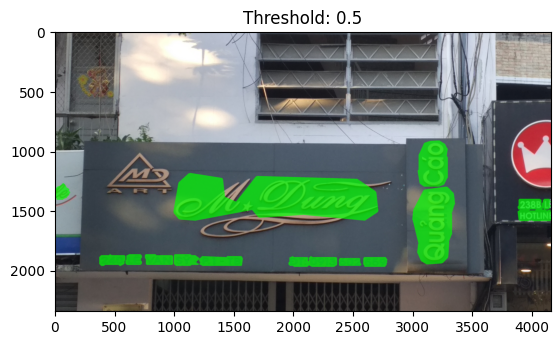

In [22]:
mask = np.zeros(image.shape[:2], np.uint8)
fill_mask = cv2.fillPoly(mask, original_contours, color=1)
prediction = overlay(image, fill_mask, color=(0, 255, 0), alpha=0.7)
plt.imshow(prediction)
plt.title(f'Threshold: {cfg.score_final_th}')
plt.show()

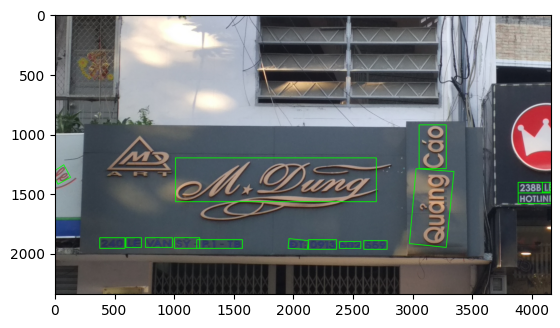

In [23]:
image2 = image.copy()
for box in original_bboxes: 
    draw_polygon(image2, box, thickness=5, color=(0, 255, 0))
plt.imshow(image2)
plt.show()

### FAST

In [10]:
%cd /kaggle/working/FAST

/kaggle/working/FAST


In [11]:
!wget https://github.com/czczup/FAST/releases/download/release/fast_base_ic15_1280_finetune_ic17mlt.pth -O fast.pth 

--2025-11-23 04:43:08--  https://github.com/czczup/FAST/releases/download/release/fast_base_ic15_1280_finetune_ic17mlt.pth
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/574992683/de500965-0b53-4414-8205-0a6094bebd4b?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-11-23T05%3A41%3A32Z&rscd=attachment%3B+filename%3Dfast_base_ic15_1280_finetune_ic17mlt.pth&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-11-23T04%3A40%3A35Z&ske=2025-11-23T05%3A41%3A32Z&sks=b&skv=2018-11-09&sig=Mv%2FoT5hvbGy5kgXUD%2BhiF5l3vmpgOzj%2BT6sJ%2F%2BNMUao%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2Mzg3NDc4OCwibmJmIjoxNzYzO

In [12]:
!pip install -q editdistance mmengine

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 452.7/452.7 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 90.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 11.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
scipy 1.10.1 requires numpy<1.27.0,>=1.19.5, but you have numpy 2.2.6 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
mkl-umath 0.1.1 requires numpy<1.27.0,>=1.26.4, but you have numpy 2.2.6 which is incompatible.
mkl-random 1.2.4 requires numpy<1.27.0

In [13]:
!sh ./compile.sh

Compiling pa.pyx because it changed.
[1/1] Cythonizing pa.pyx
/usr/local/lib/python3.11/dist-packages/Cython/Compiler/Main.py:381: FutureWarning: Cython directive 'language_level' not set, using '3str' for now (Py3). This has changed from earlier releases! File: /kaggle/working/FAST/models/post_processing/pa/pa.pyx
  tree = Parsing.p_module(s, pxd, full_module_name)
In file included from /usr/local/lib/python3.11/dist-packages/numpy/_core/include/numpy/ndarraytypes.h:1913,
                 from /usr/local/lib/python3.11/dist-packages/numpy/_core/include/numpy/ndarrayobject.h:12,
                 from /usr/local/lib/python3.11/dist-packages/numpy/_core/include/numpy/arrayobject.h:5,
                 from pa.cpp:1265:
/usr/local/lib/python3.11/dist-packages/numpy/_core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy API, disable it with " "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.htm

In [14]:
from mmengine import Config
from models import build_model
from models.utils import fuse_module, rep_model_convert, generate_bbox
from torchvision.transforms import Compose, ToTensor, Normalize

def scale_aligned_short(img, short_size=640):
    h, w = img.shape[0:2]
    scale = short_size * 1.0 / min(h, w)
    h = int(h * scale + 0.5)
    w = int(w * scale + 0.5)
    if h % 32 != 0:
        h = h + (32 - h % 32)
    if w % 32 != 0:
        w = w + (32 - w % 32)
    img = cv2.resize(img, dsize=(w, h))
    return img


class Transforms(object): 
    def __init__(self, short_size): 
        self.short_size = short_size
        self.transform = Compose([
            ToTensor(), 
            Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    def __call__(self, img): 
        img = scale_aligned_short(img, self.short_size)
        img = self.transform(img)

        return img

def inference(model, data): 
    with torch.inference_mode(): 
        outputs = model(**data)
        boxes = np.array(outputs['results'][0]['bboxes'])

    return boxes

In [40]:
cfg = Config.fromfile('config/fast/ic15/fast_base_ic15_1280_finetune_ic17mlt.py')
checkpoint_state_dict = torch.load('/kaggle/working/FAST/fast.pth', map_location=device)['ema']
new_state_dict = get_state_dict(checkpoint_state_dict)
fast = build_model(cfg.model)
fast.load_state_dict(new_state_dict, strict=True)
fast = rep_model_convert(fast)
fast = fuse_module(fast)
fast = fast.to(device).eval()

In [16]:
transforms = Transforms(cfg['data']['test']['short_size'])
cfg['test_cfg']['min_score'] = 0.5
cfg['test_cfg']['bbox_type'] = 'rect'

In [34]:
english_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/english',
                           annotation_data='/kaggle/input/signboardtext/annotations.json',
                           transforms=transforms,
                          method='fast')
vietsignboard_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard',
                               annotation_data='/kaggle/input/signboardtext/annotations.json',
                               transforms=transforms,
                                method='fast')
vin_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vin',
                        annotation_data='/kaggle/input/signboardtext/annotations.json',
                        transforms=transforms,
                      method='fast')
vietsignboard_line = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard',
                                   annotation_data='/kaggle/input/signboardtext/annotations_line.json',
                                   transforms=transforms,
                                   method='fast')

In [35]:
viet_dataloader = DataLoader(dataset=vietsignboard_ds, batch_size=1, shuffle=False, collate_fn=collate_fn)
english_dataloader = DataLoader(dataset=english_ds, batch_size=1, shuffle=False, collate_fn=collate_fn)
vin_dataloader = DataLoader(dataset=vin_ds, batch_size=1, shuffle=False, collate_fn=collate_fn)
viet_dataloaderline = DataLoader(dataset=vietsignboard_line, batch_size=1, shuffle=False, collate_fn=collate_fn)

In [42]:
img_meta = dict(
    org_img_size = [orig_size],
    img_size = [image.shape[2:]],
)
cfg.update(img_metas=img_meta)

In [43]:
print(f'Shape image: {image.shape}')
fps = measure_fps(fast, image, method='fast')
postprocess = fast.det_head.get_results
fps_and_post = measure_fps(fast, image, postprocess=postprocess, cfg=cfg, method='fast')
flops1 = measure_flops(fast.backbone, image) 
f = fast.backbone(image) 
flops2 = measure_flops(fast.neck, f)
f = fast.neck(f)
flops3 = measure_flops(fast.det_head, f)
flops = flops1 + flops2 + flops3
total_params, trainable_params, non_trainable_params = measure_params(fast)
print(f'FPS: {fps:.2f}')
print(f'FPS and PostProcess: {fps_and_post:.2f}')
print(f'PostProcess Time: {(abs(fps_and_post - fps)):.2f}')
print(f'FLOPS: {flops:.2f}')
print(f'Total Params: {total_params:.2f}')
print(f'Trainable Params: {trainable_params:.2f}')
print(f'Non Trainable Params: {non_trainable_params:.2f}')

Shape image: torch.Size([1, 3, 640, 640])
Average time per frame: 12.11 ms
Average time per frame: 65.38 ms
FPS: 82.55
FPS and PostProcess: 15.30
PostProcess Time: 67.26
FLOPS: 42.62
Total Params: 10.58
Trainable Params: 0.00
Non Trainable Params: 10.57


/kaggle/working/FAST/models/neck/fast_neck.py:28: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  return F.upsample(x, size=(H, W), mode='bilinear')
/kaggle/working/FAST/models/neck/fast_neck.py:28: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  return F.upsample(x, size=(H, W), mode='bilinear')


In [33]:
set_seed(42)
for data in tqdm(viet_dataloader): 
    file_name, image = data['file_name'][0], data['image'].to(device)
    polygons = data['polygons'][0, ...].cpu().numpy()
    orig_size = data['image_size'][0]
    transcriptions = data['transcriptions'][0]
    # Prepare data for inference
    img_meta = dict(
        org_img_size = [orig_size],
        img_size = [image.shape[2:]],
    )
    data = dict(
        imgs = image.to(device),
        img_metas = img_meta,
        cfg=cfg
    )
    boxes = inference(fast, data)
    
    save_output_txt(file_name, polygons, transcriptions, boxes)

 30%|███       | 359/1194 [03:13<06:50,  2.03it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-11.jpg


 40%|███▉      | 475/1194 [04:17<05:44,  2.09it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-3.jpg


 42%|████▏     | 497/1194 [04:28<06:22,  1.82it/s]

...

 50%|█████     | 597/1194 [05:32<05:28,  1.82it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-46.jpg


 52%|█████▏    | 623/1194 [05:46<05:18,  1.79it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-5.jpg


100%|██████████| 1194/1194 [11:04<00:00,  1.80it/s]


In [38]:
set_seed(42)
for data in tqdm(english_dataloader): 
    file_name, image = data['file_name'][0], data['image'].to(device)
    polygons = data['polygons'][0, ...].cpu().numpy()
    orig_size = data['image_size'][0]
    transcriptions = data['transcriptions'][0]
    # Prepare data for inference
    img_meta = dict(
        org_img_size = [orig_size],
        img_size = [image.shape[2:]],
    )
    data = dict(
        imgs = image.to(device),
        img_metas = img_meta,
        cfg=cfg
    )
    boxes = inference(fast, data)
    
    save_output_txt(file_name, polygons, transcriptions, boxes)

100%|██████████| 413/413 [01:38<00:00,  4.18it/s]


In [41]:
set_seed(42)
for data in tqdm(vin_dataloader): 
    file_name, image = data['file_name'][0], data['image'].to(device)
    polygons = data['polygons'][0, ...].cpu().numpy()
    orig_size = data['image_size'][0]
    transcriptions = data['transcriptions'][0]
    # Prepare data for inference
    img_meta = dict(
        org_img_size = [orig_size],
        img_size = [image.shape[2:]],
    )
    data = dict(
        imgs = image.to(device),
        img_metas = img_meta,
        cfg=cfg
    )
    boxes = inference(fast, data)
    
    save_output_txt(file_name, polygons, transcriptions, boxes)

100%|██████████| 516/516 [03:18<00:00,  2.60it/s]


In [44]:
set_seed(42)
for data in tqdm(viet_dataloaderline): 
    file_name, image = data['file_name'][0], data['image'].to(device)
    polygons = data['polygons'][0, ...].cpu().numpy()
    orig_size = data['image_size'][0]
    transcriptions = data['transcriptions'][0]
    # Prepare data for inference
    img_meta = dict(
        org_img_size = [orig_size],
        img_size = [image.shape[2:]],
    )
    data = dict(
        imgs = image.to(device),
        img_metas = img_meta,
        cfg=cfg
    )
    boxes = inference(fast, data)
    
    save_output_txt(file_name, polygons, transcriptions, boxes)

  3%|▎         | 36/1194 [00:16<07:44,  2.49it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/levansy-60.jpg


  3%|▎         | 40/1194 [00:20<15:25,  1.25it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/else-135.jpg


  3%|▎         | 41/1194 [00:21<14:35,  1.32it/s]

...

 99%|█████████▉| 1183/1194 [10:39<00:05,  2.00it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/levansy-12.jpg


100%|█████████▉| 1193/1194 [10:45<00:00,  2.05it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/else-118.jpg


100%|██████████| 1194/1194 [10:45<00:00,  1.85it/s]


In [45]:
!zip -r prediction_icdar.zip /kaggle/working/FAST/Prediction_ICDAR

  adding: kaggle/working/FAST/Prediction_ICDAR/ (stored 0%)
  adding: kaggle/working/FAST/Prediction_ICDAR/vietsignboard/ (stored 0%)
  adding: kaggle/working/FAST/Prediction_ICDAR/vietsignboard/foodstore-2.txt (deflated 64%)
  adding: kaggle/working/FAST/Prediction_ICDAR/vietsignboard/levansy-24.txt (deflated 59%)
  adding: kaggle/working/FAST/Prediction_ICDAR/vietsignboard/else-29.txt (deflated 61%)
  adding: kaggle/working/FAST/Prediction_ICDAR/vietsignboard/foodstore-6.txt (deflated 60%)
  adding: kaggle/working/FAST/Prediction_ICDAR/vietsignboard/giay-29.txt (deflated 62%)
  adding: kaggle/working/FAST/Prediction_ICDAR/vietsignboard/sportstore-30.txt (deflated 63%)
  adding: kaggle/working/FAST/Prediction_ICDAR/vietsignboard/else-62.txt (deflated 64%)
  adding: kaggle/working/FAST/Prediction_ICDAR/vietsignboard/barbershop-10.txt (deflated 58%)
  adding: kaggle/working/FAST/Prediction_ICDAR/vietsignboard/else-148.txt (deflated 62%)
  adding: kaggle/working/FAST/Prediction_ICDAR/vie

In [27]:
image = cv2.imread('/kaggle/input/signboardtext/images/train/vietsignboard/levansy-86.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
transformed_image = transforms(image).to(device)

img_meta = dict(
    org_img_size = [image.shape[:2]],
    img_size = [transformed_image.shape[1:]],
)
data = dict(
    imgs = transformed_image.unsqueeze(dim=0).to(device),
    img_metas = img_meta,
    cfg=cfg
)

with torch.inference_mode():
    outputs = fast(**data)

/kaggle/working/FAST/models/neck/fast_neck.py:28: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  return F.upsample(x, size=(H, W), mode='bilinear')


16


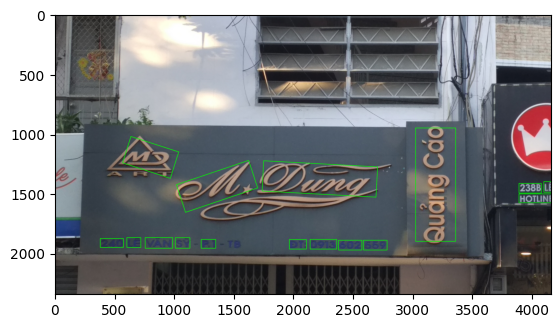

In [167]:
boxes = np.array(outputs['results'][0]['bboxes'])
print(len(boxes))
boxes = boxes.reshape(len(boxes), -1, 2)
show_image = image.copy()

for box in boxes: 
    draw_polygon(show_image, box, thickness=3, color=(0, 255, 0))

plt.imshow(show_image)
plt.show()

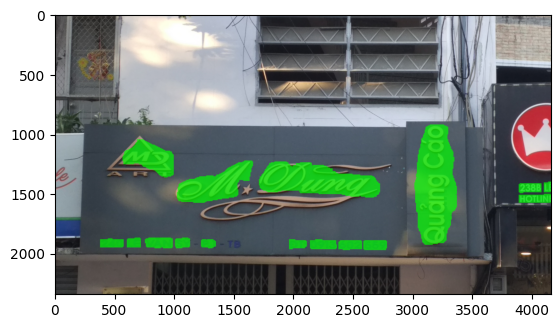

In [160]:
contours = []
for poly in outputs['results'][0]['bboxes']: 
    contours.append(np.array(poly).reshape(-1, 2))

mask = np.zeros(image.shape[:2], np.uint8)
fill_mask = cv2.fillPoly(mask, contours, color=1)
prediction = overlay(image, fill_mask, color=(0, 255, 0), alpha=0.7)
plt.imshow(prediction)
# plt.title(f'Threshold: {cfg.threshold}')
plt.show()

### PAN

In [15]:
file_id = '13m7hPZ8mhffaQwch_U6XPOvIG2ouNKHD'
url_model = f'https://drive.google.com/uc?id={file_id}'

gdown.download(url_model, 'pan.pth', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=13m7hPZ8mhffaQwch_U6XPOvIG2ouNKHD
To: /kaggle/working/FAST/pan.pth
100%|██████████| 49.1M/49.1M [00:00<00:00, 144MB/s] 


'pan.pth'

In [16]:
cfg = Config.fromfile('/kaggle/working/FAST/config/pan/pan_r18_ic15_finetune.py')
checkpoint_state_dict = torch.load('/kaggle/working/FAST/pan.pth', map_location=device)['state_dict']
new_state_dict = get_state_dict(checkpoint_state_dict)
pan = build_model(cfg.model)
pan.load_state_dict(new_state_dict, strict=True)
pan = rep_model_convert(pan)
pan = fuse_module(pan)
pan = pan.to(device)

Downloading: "http://sceneparsing.csail.mit.edu/model/pretrained_resnet/resnet18-imagenet.pth" to ./pretrained/resnet18-imagenet.pth


In [17]:
transforms = Transforms(cfg['data']['test']['short_size'])
cfg['test_cfg']['min_score'] = 0.5
cfg['test_cfg']['bbox_type'] = 'rect'
cfg['report_speed'] = False

In [43]:
english_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/english',
                           annotation_data='/kaggle/input/signboardtext/annotations.json',
                           transforms=transforms,
                          method='pan')
vietsignboard_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard',
                               annotation_data='/kaggle/input/signboardtext/annotations.json',
                               transforms=transforms,
                                method='pan')
vin_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vin',
                        annotation_data='/kaggle/input/signboardtext/annotations.json',
                        transforms=transforms,
                      method='pan')
vietsignboard_line = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard',
                                   annotation_data='/kaggle/input/signboardtext/annotations_line.json',
                                   transforms=transforms,
                                   method='pan')

In [44]:
viet_dataloader = DataLoader(dataset=vietsignboard_ds, batch_size=1, shuffle=False, collate_fn=collate_fn)
english_dataloader = DataLoader(dataset=english_ds, batch_size=1, shuffle=False, collate_fn=collate_fn)
vin_dataloader = DataLoader(dataset=vin_ds, batch_size=1, shuffle=False, collate_fn=collate_fn)
viet_dataloaderline = DataLoader(dataset=vietsignboard_line, batch_size=1, shuffle=False, collate_fn=collate_fn)

In [22]:
img_meta = dict(
    org_img_size = [orig_size],
    img_size = [image.shape[2:]],
)
cfg.update(img_metas=img_meta)

In [23]:
print(f'Shape image: {image.shape}')
fps = measure_fps(pan, image, method='pan')
postprocess = pan.det_head.get_results
fps_and_post = measure_fps(pan, image, postprocess=postprocess, cfg=cfg, method='pan')
flops1 = measure_flops(pan.backbone, image) 
f = pan.backbone(image)
flops2 = measure_flops(pan.reduce_layer1, f[0]) 
flops3 = measure_flops(pan.reduce_layer2, f[1]) 
flops4 = measure_flops(pan.reduce_layer3, f[2]) 
flops5 = measure_flops(pan.reduce_layer4, f[3]) 

f1 = pan.reduce_layer1(f[0])
f2 = pan.reduce_layer2(f[1])
f3 = pan.reduce_layer3(f[2])
f4 = pan.reduce_layer4(f[3])

# FPEM
flops6 = measure_flops(pan.fpem1, (f1, f2, f3, f4)) 
f1_1, f2_1, f3_1, f4_1 = pan.fpem1(f1, f2, f3, f4)
flops7 = measure_flops(pan.fpem2, (f1_1, f2_1, f3_1, f4_1))
f1_2, f2_2, f3_2, f4_2 = pan.fpem2(f1_1, f2_1, f3_1, f4_1)

# FFM
f1 = f1_1 + f1_2
f2 = f2_1 + f2_2
f3 = f3_1 + f3_2
f4 = f4_1 + f4_2
f2 = pan._upsample(f2, f1.size())
f3 = pan._upsample(f3, f1.size())
f4 = pan._upsample(f4, f1.size())
f = torch.cat((f1, f2, f3, f4), 1)
flops8 = measure_flops(pan.det_head, f)
flops = flops1 + flops2 + flops3 + flops4 + flops5 + flops6 + flops7 + flops8
total_params, trainable_params, non_trainable_params = measure_params(pan)
print(f'FPS: {fps:.2f}')
print(f'FPS and PostProcess: {fps_and_post:.2f}')
print(f'PostProcess Time: {(abs(fps_and_post - fps)):.2f}')
print(f'FLOPS: {flops:.2f}')
print(f'Total Params: {total_params:.2f}')
print(f'Trainable Params: {trainable_params:.2f}')
print(f'Non Trainable Params: {non_trainable_params:.2f}')

Shape image: torch.Size([1, 3, 640, 640])


/kaggle/working/FAST/models/neck/fpem_v1.py:30: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  return F.upsample(x, size=(H, W), mode='bilinear') + y
/kaggle/working/FAST/models/pan.py:33: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  return F.upsample(x, size=(H // scale, W // scale), mode='bilinear')


Average time per frame: 13.21 ms
Average time per frame: 634.02 ms
FPS: 75.68
FPS and PostProcess: 1.58
PostProcess Time: 74.11
FLOPS: 43.55
Total Params: 12.25
Trainable Params: 12.25
Non Trainable Params: 0.00


/kaggle/working/FAST/models/neck/fpem_v1.py:30: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  return F.upsample(x, size=(H, W), mode='bilinear') + y
/kaggle/working/FAST/models/neck/fpem_v1.py:30: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  return F.upsample(x, size=(H, W), mode='bilinear') + y
/kaggle/working/FAST/models/neck/fpem_v1.py:30: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  return F.upsample(x, size=(H, W), mode='bilinear') + y
/kaggle/working/FAST/models/neck/fpem_v1.py:30: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  return F.upsample(x, size=(H, W), mode='bilinear') + y
/kaggle/working/FAST/models/pan.py:33: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  return F.upsample(x, size=(H // scale, W // scale), mode='bilinear')


In [48]:
set_seed(42)
for data in tqdm(viet_dataloader): 
    file_name, image = data['file_name'][0], data['image'].to(device)
    polygons = data['polygons'][0, ...].cpu().numpy()
    orig_size = data['image_size'][0]
    transcriptions = data['transcriptions'][0]
    # Prepare data for inference
    img_meta = dict(
        org_img_size = [orig_size],
        img_size = [image.shape[2:]],
    )
    data = dict(
        imgs = image.to(device),
        img_metas = img_meta,
        cfg=cfg
    )
    boxes = inference(pan, data)
    
    save_output_txt(file_name, polygons, transcriptions, boxes)

 30%|███       | 359/1194 [01:13<02:32,  5.48it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-11.jpg


 40%|███▉      | 476/1194 [01:37<02:02,  5.88it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-3.jpg


 42%|████▏     | 498/1194 [01:41<01:54,  6.07it/s]

...

 50%|█████     | 597/1194 [02:05<02:01,  4.90it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-46.jpg


 52%|█████▏    | 624/1194 [02:11<02:01,  4.68it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-5.jpg


100%|██████████| 1194/1194 [04:10<00:00,  4.76it/s]


In [52]:
set_seed(42)
for data in tqdm(english_dataloader): 
    file_name, image = data['file_name'][0], data['image'].to(device)
    polygons = data['polygons'][0, ...].cpu().numpy()
    orig_size = data['image_size'][0]
    transcriptions = data['transcriptions'][0]
    # Prepare data for inference
    img_meta = dict(
        org_img_size = [orig_size],
        img_size = [image.shape[2:]],
    )
    data = dict(
        imgs = image.to(device),
        img_metas = img_meta,
        cfg=cfg
    )
    boxes = inference(pan, data)
    
    save_output_txt(file_name, polygons, transcriptions, boxes)

100%|██████████| 413/413 [00:41<00:00,  9.99it/s]


In [55]:
set_seed(42)
for data in tqdm(vin_dataloader): 
    file_name, image = data['file_name'][0], data['image'].to(device)
    polygons = data['polygons'][0, ...].cpu().numpy()
    orig_size = data['image_size'][0]
    transcriptions = data['transcriptions'][0]
    # Prepare data for inference
    img_meta = dict(
        org_img_size = [orig_size],
        img_size = [image.shape[2:]],
    )
    data = dict(
        imgs = image.to(device),
        img_metas = img_meta,
        cfg=cfg
    )
    boxes = inference(pan, data)
    
    save_output_txt(file_name, polygons, transcriptions, boxes)

100%|██████████| 516/516 [01:20<00:00,  6.41it/s]


In [58]:
set_seed(42)
for data in tqdm(viet_dataloaderline): 
    file_name, image = data['file_name'][0], data['image'].to(device)
    polygons = data['polygons'][0, ...].cpu().numpy()
    orig_size = data['image_size'][0]
    transcriptions = data['transcriptions'][0]
    # Prepare data for inference
    img_meta = dict(
        org_img_size = [orig_size],
        img_size = [image.shape[2:]],
    )
    data = dict(
        imgs = image.to(device),
        img_metas = img_meta,
        cfg=cfg
    )
    boxes = inference(pan, data)
    
    save_output_txt(file_name, polygons, transcriptions, boxes)

  3%|▎         | 35/1194 [00:06<03:20,  5.78it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/levansy-60.jpg


  3%|▎         | 40/1194 [00:07<05:46,  3.33it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/else-135.jpg


  3%|▎         | 41/1194 [00:08<05:29,  3.49it/s]

...

 99%|█████████▉| 1184/1194 [03:55<00:01,  5.15it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/levansy-12.jpg


100%|█████████▉| 1193/1194 [03:57<00:00,  5.32it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/else-118.jpg


100%|██████████| 1194/1194 [03:57<00:00,  5.03it/s]


In [59]:
!zip -r prediction_icdar.zip /kaggle/working/FAST/Prediction_ICDAR

  adding: kaggle/working/FAST/Prediction_ICDAR/ (stored 0%)
  adding: kaggle/working/FAST/Prediction_ICDAR/vietsignboard/ (stored 0%)
  adding: kaggle/working/FAST/Prediction_ICDAR/vietsignboard/sportstore-8.txt (deflated 63%)
  adding: kaggle/working/FAST/Prediction_ICDAR/vietsignboard/phothong-11.txt (deflated 65%)
  adding: kaggle/working/FAST/Prediction_ICDAR/vietsignboard/taphoa-16.txt (deflated 67%)
  adding: kaggle/working/FAST/Prediction_ICDAR/vietsignboard/clinic-12.txt (deflated 61%)
  adding: kaggle/working/FAST/Prediction_ICDAR/vietsignboard/milkteastore-24.txt (deflated 66%)
  adding: kaggle/working/FAST/Prediction_ICDAR/vietsignboard/milkteastore-38.txt (deflated 64%)
  adding: kaggle/working/FAST/Prediction_ICDAR/vietsignboard/phothong-14.txt (deflated 57%)
  adding: kaggle/working/FAST/Prediction_ICDAR/vietsignboard/fashionshop-74.txt (deflated 65%)
  adding: kaggle/working/FAST/Prediction_ICDAR/vietsignboard/barbershop-24.txt (deflated 60%)
  adding: kaggle/working/FAS

In [38]:
image = cv2.imread('/kaggle/input/signboardtext/images/train/vietsignboard/levansy-86.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
transformed_image = transforms(image).to(device)

img_meta = dict(
    org_img_size = [image.shape[:2]],
    img_size = [transformed_image.shape[1:]],
)
data = dict(
    imgs = transformed_image.unsqueeze(dim=0).to(device),
    img_metas = img_meta,
    cfg=cfg
)

pan.eval()
with torch.inference_mode():
    outputs = pan(**data)

18


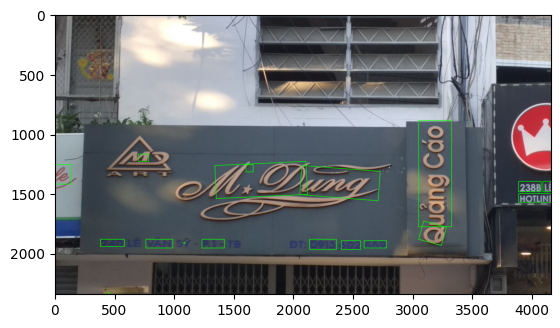

In [35]:
boxes = np.array(outputs['results'][0]['bboxes'])
print(len(boxes))
boxes = boxes.reshape(len(boxes), -1, 2)
show_image = image.copy()

for box in boxes: 
    draw_polygon(show_image, box, thickness=3, color=(0, 255, 0))

plt.imshow(show_image)
plt.show()

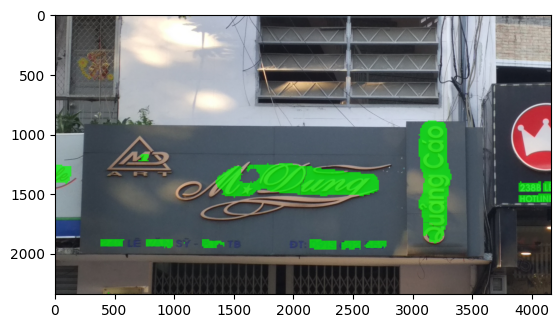

In [39]:
contours = []
for poly in outputs['results'][0]['bboxes']: 
    contours.append(np.array(poly).reshape(-1, 2))

mask = np.zeros(image.shape[:2], np.uint8)
fill_mask = cv2.fillPoly(mask, contours, color=1)
prediction = overlay(image, fill_mask, color=(0, 255, 0), alpha=0.7)
plt.imshow(prediction)
# plt.title(f'Threshold: {cfg.threshold}')
plt.show()

### DBNET++

In [10]:
%cd /kaggle/working/PaddleOCR2Pytorch

/kaggle/working/PaddleOCR2Pytorch


In [11]:
file_id = '1fC64s4wkNQm5yh11A2qbeklfZr-BGRS0'
url_model = f'https://drive.google.com/uc?id={file_id}'

gdown.download(url_model, 'dbnet.pth', quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1fC64s4wkNQm5yh11A2qbeklfZr-BGRS0
From (redirected): https://drive.google.com/uc?id=1fC64s4wkNQm5yh11A2qbeklfZr-BGRS0&confirm=t&uuid=26443adb-e08f-47f2-9234-2ece09351112
To: /kaggle/working/PaddleOCR2Pytorch/dbnet.pth
100%|██████████| 106M/106M [00:01<00:00, 66.5MB/s] 


'dbnet.pth'

In [12]:
import yaml
from pytorchocr.modeling.architectures.base_model import BaseModel
from pytorchocr.data.imaug import create_operators, transform
from pytorchocr.postprocess import build_post_process

class Preprocess(object): 
    def __init__(self, list_preprocess):
        self.list_preprocess = list_preprocess
        self.preprocess_op = create_operators(list_preprocess)
    def __call__(self, data):
        assert isinstance(data, dict)
        data = transform(data, ops=self.preprocess_op)
        transformed_image = data[0]
        shape_list = data[1]
            
        return transformed_image, shape_list

def parse_yaml(config_file): 
    with open(config_file, 'r') as f: 
        cfg = yaml.load(f, yaml.SafeLoader)

    return cfg

def inference(model, image, shape_list, postprocess): 
    model.eval() 

    with torch.inference_mode(): 
        outputs = model(image)
        preds = dict(
            maps = outputs['maps'].cpu().numpy()
        )
        results = postprocess(preds, shape_list)[0]
        boxes = results['points']

    return boxes

In [23]:
config = parse_yaml('configs/det/det_r50_db++_icdar15.yml')
checkpoint_state_dict = torch.load('/kaggle/working/PaddleOCR2Pytorch/dbnet.pth', map_location=device)
dbnet = BaseModel(config['Architecture'])
dbnet.load_state_dict(checkpoint_state_dict, strict=True)
dbnet = dbnet.to(device)

In [14]:
list_preprocess = config['Eval']['dataset']['transforms'][2:]
list_preprocess[3]['KeepKeys']['keep_keys'] = ['image', 'shape']
transforms = Preprocess(list_preprocess)
config['PostProcess']['box_thresh'] = 0.5
postprocess = build_post_process(config['PostProcess'])

In [15]:
def collate_fn(batch): 
    return {
        'file_name': [b['file_name'] for b in batch],
        'image_size': [b['image_size'] for b in batch],
        'shape_list': [b['shape_list'] for b in batch],
        'image': torch.stack([b['image'] for b in batch]),
        'polygons': torch.stack([b['polygons'] for b in batch]),
        'transcriptions': [b['transcriptions'] for b in batch]
    }

In [17]:
english_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/english',
                           annotation_data='/kaggle/input/signboardtext/annotations.json',
                           transforms=transforms,
                          method='dbnet')
vietsignboard_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard',
                               annotation_data='/kaggle/input/signboardtext/annotations.json',
                               transforms=transforms,
                                method='dbnet')
vin_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vin',
                        annotation_data='/kaggle/input/signboardtext/annotations.json',
                        transforms=transforms,
                      method='dbnet')
vietsignboard_line = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard',
                                   annotation_data='/kaggle/input/signboardtext/annotations_line.json',
                                   transforms=transforms,
                                   method='dbnet')

In [55]:
viet_dataloader = DataLoader(dataset=vietsignboard_ds, batch_size=1, shuffle=False, collate_fn=collate_fn)
english_dataloader = DataLoader(dataset=english_ds, batch_size=1, shuffle=False, collate_fn=collate_fn)
vin_dataloader = DataLoader(dataset=vin_ds, batch_size=1, shuffle=False, collate_fn=collate_fn)
viet_dataloaderline = DataLoader(dataset=vietsignboard_line, batch_size=1, shuffle=False, collate_fn=collate_fn)

In [24]:
from types import SimpleNamespace
resize_h, resize_w = image.shape[2:]
orig_h, orig_w = orig_size
ratio_h = float(resize_h) / orig_h
ratio_w = float(resize_w) / orig_w
shape_list = np.array([orig_h, orig_w, ratio_h, ratio_w])
shape_list = np.expand_dims(shape_list, axis=0)
config.update(dict(shape_list=shape_list))

In [25]:
print(f'Shape image: {image.shape}')
fps = measure_fps(dbnet, image, method='dbnet++')
fps_and_post = measure_fps(dbnet, image, postprocess=postprocess, cfg=SimpleNamespace(**config), method='dbnet++')
flops = measure_flops(dbnet, image)
total_params, trainable_params, non_trainable_params = measure_params(dbnet)
print(f'FPS: {fps:.2f}')
print(f'FPS and PostProcess: {fps_and_post:.2f}')
print(f'PostProcess Time: {(abs(fps_and_post - fps)):.2f}')
print(f'FLOPS: {flops:.2f}')
print(f'Total Params: {total_params:.2f}')
print(f'Trainable Params: {trainable_params:.2f}')
print(f'Non Trainable Params: {non_trainable_params:.2f}')

Shape image: torch.Size([1, 3, 640, 640])
Average time per frame: 27.87 ms
Average time per frame: 53.51 ms
FPS: 35.88
FPS and PostProcess: 18.69
PostProcess Time: 17.19
FLOPS: 39.01
Total Params: 26.43
Trainable Params: 26.43
Non Trainable Params: 0.00


In [40]:
set_seed(42)
for data in tqdm(viet_dataloader): 
    file_name, image = data['file_name'][0], data['image'].to(device)
    polygons = data['polygons'][0, ...].cpu().numpy()
    orig_size = data['image_size'][0]
    shape_list = np.expand_dims(data['shape_list'][0], axis=0)
    transcriptions = data['transcriptions'][0]
    boxes = inference(dbnet, image, shape_list, postprocess)
    
    save_output_txt(file_name, polygons, transcriptions, boxes)

 30%|███       | 359/1194 [01:34<03:32,  3.94it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-11.jpg


 40%|███▉      | 475/1194 [02:05<03:05,  3.88it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-3.jpg


 42%|████▏     | 497/1194 [02:11<03:09,  3.68it/s]

...

 50%|█████     | 597/1194 [02:38<02:43,  3.65it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-46.jpg


 52%|█████▏    | 623/1194 [02:45<02:28,  3.84it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-5.jpg


100%|██████████| 1194/1194 [05:17<00:00,  3.76it/s]


In [44]:
set_seed(42)
for data in tqdm(english_dataloader): 
    file_name, image = data['file_name'][0], data['image'].to(device)
    polygons = data['polygons'][0, ...].cpu().numpy()
    orig_size = data['image_size'][0]
    shape_list = np.expand_dims(data['shape_list'][0], axis=0)
    transcriptions = data['transcriptions'][0]
    boxes = inference(dbnet, image, shape_list, postprocess)
    
    save_output_txt(file_name, polygons, transcriptions, boxes)

100%|██████████| 413/413 [01:43<00:00,  3.98it/s]


In [47]:
set_seed(42)
for data in tqdm(vin_dataloader): 
    file_name, image = data['file_name'][0], data['image'].to(device)
    polygons = data['polygons'][0, ...].cpu().numpy()
    orig_size = data['image_size'][0]
    shape_list = np.expand_dims(data['shape_list'][0], axis=0)
    transcriptions = data['transcriptions'][0]
    boxes = inference(dbnet, image, shape_list, postprocess)
    
    save_output_txt(file_name, polygons, transcriptions, boxes)

100%|██████████| 516/516 [02:14<00:00,  3.84it/s]


In [50]:
set_seed(42)
for data in tqdm(viet_dataloaderline): 
    file_name, image = data['file_name'][0], data['image'].to(device)
    polygons = data['polygons'][0, ...].cpu().numpy()
    orig_size = data['image_size'][0]
    shape_list = np.expand_dims(data['shape_list'][0], axis=0)
    transcriptions = data['transcriptions'][0]
    boxes = inference(dbnet, image, shape_list, postprocess)
    
    save_output_txt(file_name, polygons, transcriptions, boxes)

  3%|▎         | 36/1194 [00:09<04:43,  4.09it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/levansy-60.jpg


  3%|▎         | 40/1194 [00:10<05:01,  3.83it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/else-135.jpg


  3%|▎         | 41/1194 [00:10<04:54,  3.92it/s]

...

 99%|█████████▉| 1183/1194 [04:59<00:02,  3.90it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/levansy-12.jpg


100%|█████████▉| 1193/1194 [05:01<00:00,  4.03it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/else-118.jpg


100%|██████████| 1194/1194 [05:01<00:00,  3.95it/s]


In [51]:
!zip -r prediction_icdar.zip /kaggle/working/PaddleOCR2Pytorch/Prediction_ICDAR

  adding: kaggle/working/PaddleOCR2Pytorch/Prediction_ICDAR/ (stored 0%)
  adding: kaggle/working/PaddleOCR2Pytorch/Prediction_ICDAR/vietsignboard/ (stored 0%)
  adding: kaggle/working/PaddleOCR2Pytorch/Prediction_ICDAR/vietsignboard/fashionshop-87.txt (deflated 55%)
  adding: kaggle/working/PaddleOCR2Pytorch/Prediction_ICDAR/vietsignboard/sportstore-18.txt (deflated 55%)
  adding: kaggle/working/PaddleOCR2Pytorch/Prediction_ICDAR/vietsignboard/phothong-4.txt (deflated 59%)
  adding: kaggle/working/PaddleOCR2Pytorch/Prediction_ICDAR/vietsignboard/milkteastore-12.txt (deflated 52%)
  adding: kaggle/working/PaddleOCR2Pytorch/Prediction_ICDAR/vietsignboard/fashionshop-76.txt (deflated 60%)
  adding: kaggle/working/PaddleOCR2Pytorch/Prediction_ICDAR/vietsignboard/else-92.txt (deflated 51%)
  adding: kaggle/working/PaddleOCR2Pytorch/Prediction_ICDAR/vietsignboard/trunghoc-9.txt (deflated 54%)
  adding: kaggle/working/PaddleOCR2Pytorch/Prediction_ICDAR/vietsignboard/barbershop-39.txt (deflat

In [129]:
set_seed(seed=42)
image = cv2.imread('/kaggle/input/signboardtext/images/train/vietsignboard/levansy-86.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

data = dict(image = image)
transformed_image, shape_list = transforms(data)
if isinstance(transformed_image, np.ndarray): 
    transformed_image = torch.from_numpy(transformed_image)
shape_list = np.expand_dims(shape_list, axis=0)

with torch.inference_mode(): 
    outputs = dbnet(transformed_image.unsqueeze(dim=0))

preds = dict(maps = outputs['maps'].cpu().numpy())

results = postprocess(preds, shape_list)

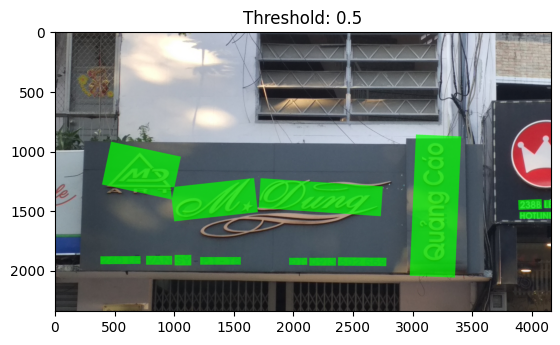

In [145]:
mask = np.zeros(image.shape[:2], np.uint8)
fill_mask = cv2.fillPoly(mask, results[0]['points'].astype(np.int32), color=1)
prediction = overlay(image, fill_mask, color=(0, 255, 0), alpha=0.7)
plt.imshow(prediction)
plt.title(f"Threshold: {config['PostProcess']['box_thresh']}")
plt.show()

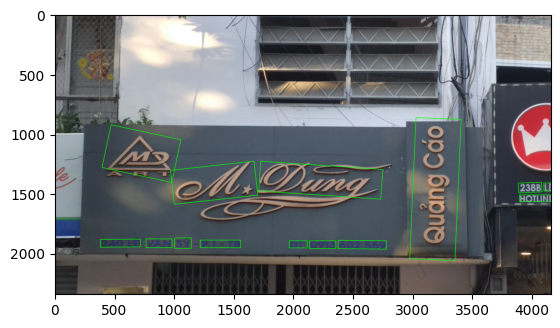

In [136]:
show_image = image.copy()

for box in results[0]['points']: 
    draw_polygon(show_image, box, thickness=3, color=(0, 255, 0))

plt.imshow(show_image)
plt.show()